In [ ]:
!pip install matplotlib seaborn


In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Path to the uploaded file
file_path = '//content/heart_failure_clinical_records_dataset.csv'  # Adjust this to match the uploaded file's name

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# Define the dependent and independent variables
X = df[['age']]
y = df['high_blood_pressure']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Add a constant to the independent variables
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

# Fit the regression model
model = sm.OLS(y_train, X_train).fit()


In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)
print(model.summary())


                             OLS Regression Results                            
Dep. Variable:     high_blood_pressure   R-squared:                       0.005
Model:                             OLS   Adj. R-squared:                  0.001
Method:                  Least Squares   F-statistic:                     1.167
Date:                 Tue, 23 Jul 2024   Prob (F-statistic):              0.281
Time:                         20:48:14   Log-Likelihood:                -161.84
No. Observations:                  239   AIC:                             327.7
Df Residuals:                      237   BIC:                             334.6
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1811      0.161      1.12

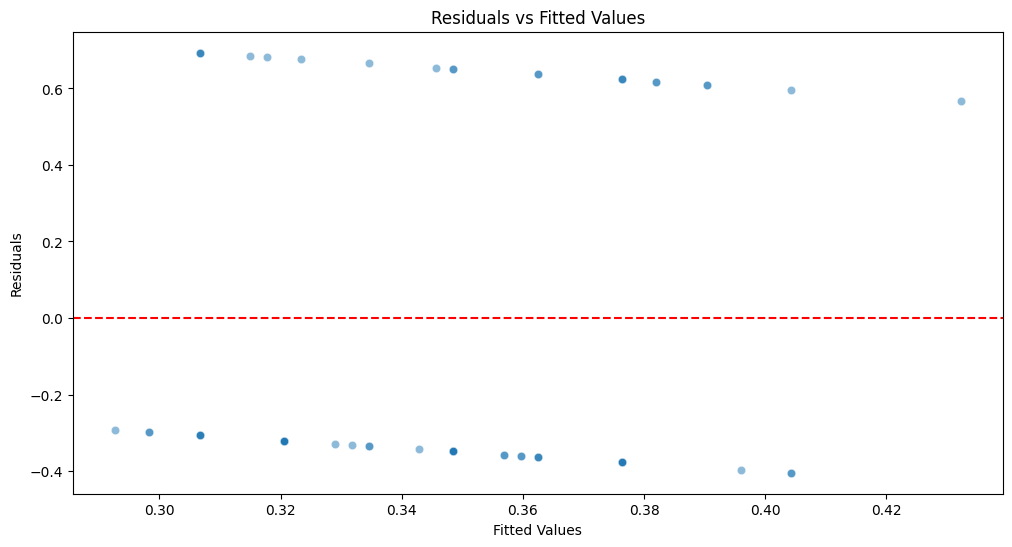

In [ ]:
# Calculate residuals
residuals = y_test - y_pred

# Residuals Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()


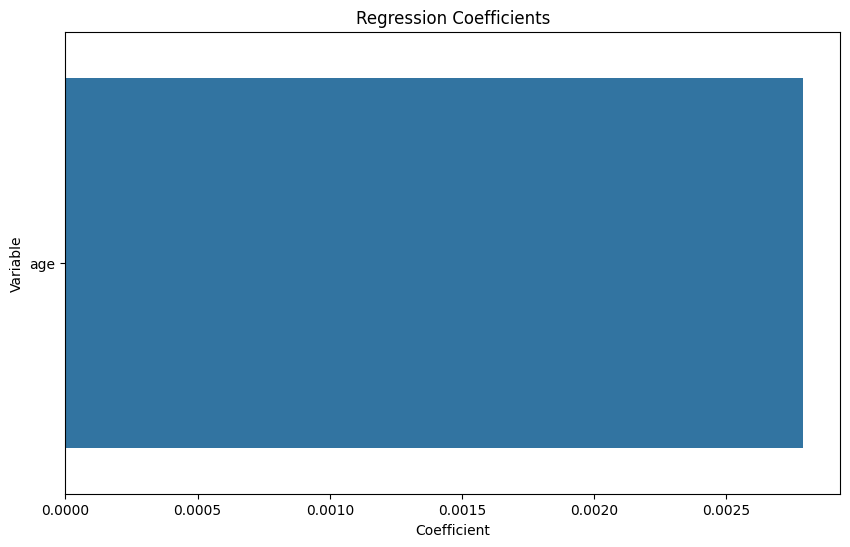

In [ ]:
# Coefficient Plot
coef = model.params[1:]  # Exclude the constant term
coef_df = pd.DataFrame({
    'Variable': coef.index,
    'Coefficient': coef.values
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Variable', data=coef_df, orient='h')
plt.title('Regression Coefficients')
plt.show()


In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
#mae = mean_absolute_error(y_test, y_pred)
#r2 = r2_score(y_test, y_pred)

# Print the metrics
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
#print(f'Mean Absolute Error (MAE): {mae}')
#print(f'R-squared (R²): {r2}')

Mean Squared Error (MSE): 0.22271516683154932
Root Mean Squared Error (RMSE): 0.47192707787490784
R-squared (R²): 0.021032233707475756
